Animators care about clean lines and specific art styles.

To build this AI, we first need to teach it what "good" motion looks like. We do this by "breaking" existing animation and asking the AI to fix it.

self supervised learning
-first we take finished high quality animation video to first train it 
-extarct three frames 
-pretend frame 2 does not exist 
-tell the ai what the frame 2 will look like 
-compare ai generated frame with the ral frame .

import libraries 
video path - where the vodoes are saved
output dir - path wherehte output will be saved 

In [4]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # Specialized progress bar for Jupyter

# --- CONFIGURATION ---
VIDEO_PATH = 'raw_videos/my_animation.mp4' 
OUTPUT_DIR = 'dataset/triplets'
SCENE_THRESHOLD = 30.0 

the function where the triplets are shown 

In [5]:
def show_triplet(prev, curr, next_frame):
    """Helper to display images side-by-side in Jupyter"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Convert BGR (OpenCV) to RGB (Matplotlib)
    axes[0].imshow(cv2.cvtColor(prev, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Frame t-1 (Input A)")
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(curr, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Frame t (Target)")
    axes[1].axis('off')
    
    axes[2].imshow(cv2.cvtColor(next_frame, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Frame t+1 (Input B)")
    axes[2].axis('off')
    
    plt.show()

1. The "Sliding Window" Technique We don't just read one frame at a time; we read a sequence.

frame_prev is your Input A (Start).

frame_curr is your Target (The middle frame we want to learn to generate).

frame_next is your Input B (End). After saving, we shift everything over: prev becomes the old curr, and we read a new next.

2. np.mean(np.abs(...)) (The Cut Detector) In animation, scene cuts are instant.

If we try to interpolate between a scene of a "Face" and a scene of a "Car", the AI will generate a monstrous morph of a face-car. This ruins training.

This math checks the pixel difference. If the average pixel changes by more than 30 (out of 255), we assume it's a cut and ignore that triplet.

3. Naming Convention (_0, _1, _2) This is critical for the Dataset Loader we will write later. It ensures the computer knows which image is the "Start", which is the "Middle", and which is the "End" just by looking at the filename.

🎬 Processing my_animation...


  0%|          | 0/300 [00:00<?, ?it/s]

Captured Triplet #0 (Diff: 0.00)


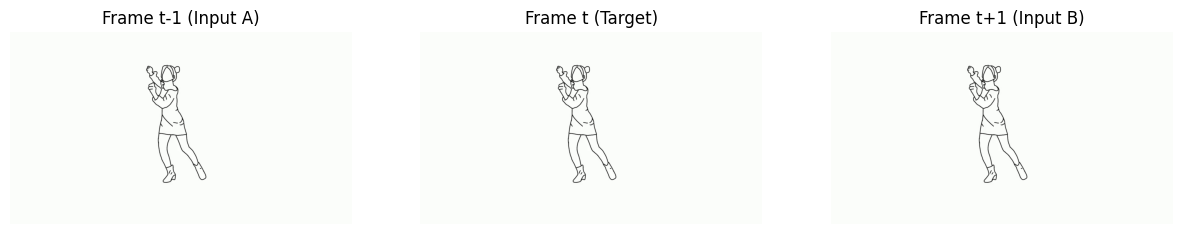

100%|██████████| 300/300 [00:42<00:00,  7.02it/s]

✅ Done. Saved 300 triplets to dataset/triplets\my_animation


In [6]:

# --- MAIN EXECUTION ---
if not os.path.exists(VIDEO_PATH):
    print(f"❌ Error: Please upload a video to {VIDEO_PATH}")
else:
    # 1. Setup
    cap = cv2.VideoCapture(VIDEO_PATH)
    video_name = os.path.splitext(os.path.basename(VIDEO_PATH))[0]
    save_path = os.path.join(OUTPUT_DIR, video_name)
    os.makedirs(save_path, exist_ok=True)

    ret1, prev = cap.read()
    ret2, curr = cap.read()
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    saved_count = 0
    
    print(f"🎬 Processing {video_name}...")

    # 2. Loop with Progress Bar
    for _ in tqdm(range(total_frames - 2)):
        ret3, next_frame = cap.read()
        if not ret3: break

        # Calculate difference
        diff1 = np.mean(np.abs(prev.astype(float) - curr.astype(float)))
        diff2 = np.mean(np.abs(curr.astype(float) - next_frame.astype(float)))

        # Check for Scene Cuts
        if diff1 < SCENE_THRESHOLD and diff2 < SCENE_THRESHOLD:
            # Save the images
            uid = f"{saved_count:05d}"
            cv2.imwrite(f"{save_path}/{uid}_0.png", prev)
            cv2.imwrite(f"{save_path}/{uid}_1.png", curr)
            cv2.imwrite(f"{save_path}/{uid}_2.png", next_frame)
            
            # --- VISUALIZATION CHECK ---
            # Show the first triplet found, then every 500th triplet
            # This lets you verify it's working without spamming the screen
            if saved_count == 0 or saved_count % 500 == 0:
                print(f"Captured Triplet #{saved_count} (Diff: {diff1:.2f})")
                show_triplet(prev, curr, next_frame)
            
            saved_count += 1
        
        # Shift Window
        prev = curr
        curr = next_frame

    cap.release()
    print(f"✅ Done. Saved {saved_count} triplets to {save_path}")

    